# Generative Agents — a stripped-down memory + reflection demo

*Week 4 companion for the 🟦 Park et al. (2023) discussion (Bhuvanesh).*

![Smallville cover](4_smallville_assets/smallville_cover.png)

The original [`joonspk-research/generative_agents`](https://github.com/joonspk-research/generative_agents) repo runs a Phaser game engine + Django server + 25-agent town for two simulated days, and cost the authors *thousands of dollars* in API credits. We don't need any of that to understand what the paper actually contributes. The headline architectural moves — **a memory stream with a recency × importance × relevance retrieval rule, and a reflection mechanism that turns observations into higher-level beliefs** — fit in a single notebook.

This notebook strips Smallville to the architecture and skips the world. There is no map, no path-finding, no sandbox — just three agents, a few text observations, and the cognitive plumbing the paper proposes.

### What we keep, what we drop

| Park et al. 2023 §4 | This notebook |
|---|---|
| Memory stream (timestamped natural-language log) | ✅ Section 1 |
| Importance score (LLM-rated 1–10) | ✅ Section 1.2 |
| Recency (exponential decay) | ✅ Section 1.3 |
| Relevance (cosine similarity on embeddings) | ✅ Section 1.4 |
| Composite retrieval | ✅ Section 1.5 |
| Reflection (questions → insights) | ✅ Section 2 |
| Two-agent dialogue + information transfer | ✅ Section 3 |
| Planning (top-down day plan, recursive decomposition) | ❌ skipped |
| 25 agents, sandbox, Phaser, path-finding | ❌ skipped |
| 2 simulated days of emergent behaviour | ❌ skipped |

We skip planning because it is the most code for the least new insight in a single class hour — it's recursive prompt-decomposition, conceptually a smaller move than memory + reflection. The architecture diagram below shows where we land in the paper's framework: *Perceive → Memory Stream → Retrieve → Retrieved Memories → Reflect / Act.* (Plan, dashed out for us, runs in parallel on the right.)

![Park 2023 Figure 5 — generative agent architecture](4_smallville_assets/fig5_architecture.png)

---

## 0. Setup

The notebook runs in two modes:

- **Live mode** — set `OPENAI_API_KEY` in the environment before launching Jupyter. All LLM and embedding calls hit the API and results are cached to `4_smallville_cache/llm_cache.json` so re-runs are free.
- **Cached mode** — no API key needed. Reads only from the cache shipped in the repo. Every cell still produces output; nothing requires live calls if the cache covers the prompts in the notebook.

Pre-running the notebook once with a key produces the cache the rest of the class reads from.

### How much does it cost to run?

Running the **entire notebook end-to-end with no cache** (every LLM and embedding call goes to OpenAI) costs **roughly 0.5–1 US cent** at current `gpt-4o-mini` and `text-embedding-3-small` pricing (Apr 2026: $0.15 / 1M input and $0.60 / 1M output tokens for `gpt-4o-mini`; $0.02 / 1M tokens for `text-embedding-3-small`). On the order of **50 chat completions** (importance ratings, reflection, dialogue, summaries) and **~50 embeddings** (one per memory + one per query).

Running the notebook with the **shipped cache**: free. Every prompt in the notebook is keyed by `(model, prompt, temperature)` in `4_smallville_cache/llm_cache.json` and a hit returns the cached response without an API call. The cell at the very bottom prints the actual cost of *your* run.

In [1]:
import os

#os.environ["OPENAI_API_KEY"] = "sk-"

import json
import math
import hashlib
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd

CACHE_DIR = Path('4_smallville_cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / 'llm_cache.json'

# Load cache
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
else:
    _cache = {}

api_key = os.environ.get('OPENAI_API_KEY')
if api_key:
    import openai
    client = openai.OpenAI(api_key=api_key)
    print(f'Live mode: OpenAI client ready. Cache has {len(_cache)} entries.')
else:
    client = None
    print(f'Cached mode: no OPENAI_API_KEY. Cache has {len(_cache)} entries.')


# --- token usage and pricing (April 2026 OpenAI rates, per 1M tokens) ---
PRICING_PER_TOKEN = {
    'gpt-4o-mini':            {'in': 0.15 / 1e6, 'out': 0.60 / 1e6},
    'text-embedding-3-small': {'in': 0.02 / 1e6, 'out': 0.0},
}
# Counters: { (model, 'in'|'out'): total_tokens }, plus call counts
_usage = {'tokens': {}, 'calls': {'chat_live': 0, 'chat_cached': 0, 'embed_live': 0, 'embed_cached': 0}}


def _bump(model, kind, n):
    _usage['tokens'][(model, kind)] = _usage['tokens'].get((model, kind), 0) + n


def _cache_key(kind, model, payload):
    h = hashlib.sha256(json.dumps([kind, model, payload], sort_keys=True).encode()).hexdigest()[:16]
    return f'{kind}:{model}:{h}'


def _save_cache():
    with open(CACHE_FILE, 'w') as f:
        json.dump(_cache, f, indent=2)


def llm(prompt, model='gpt-4o-mini', temperature=0.7, max_tokens=400):
    """Single-prompt completion. Cached by (model, prompt, temperature)."""
    key = _cache_key('chat', model, {'prompt': prompt, 'temperature': temperature})
    if key in _cache:
        _usage['calls']['chat_cached'] += 1
        return _cache[key]
    if client is None:
        raise RuntimeError(f'Prompt not in cache and no API key set:\n{prompt[:200]}...')
    r = client.chat.completions.create(
        model=model,
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[{'role': 'user', 'content': prompt}],
    )
    out = r.choices[0].message.content.strip()
    _bump(model, 'in',  r.usage.prompt_tokens)
    _bump(model, 'out', r.usage.completion_tokens)
    _usage['calls']['chat_live'] += 1
    _cache[key] = out
    _save_cache()
    return out


def embed(text, model='text-embedding-3-small'):
    """Embed one string. Cached by (model, text)."""
    key = _cache_key('embed', model, {'text': text})
    if key in _cache:
        _usage['calls']['embed_cached'] += 1
        return np.array(_cache[key])
    if client is None:
        raise RuntimeError(f'Embedding not in cache and no API key set: {text[:80]}')
    r = client.embeddings.create(model=model, input=text)
    vec = r.data[0].embedding
    _bump(model, 'in', r.usage.prompt_tokens)
    _usage['calls']['embed_live'] += 1
    _cache[key] = vec
    _save_cache()
    return np.array(vec)


def print_cost_summary():
    """Print a per-model breakdown of tokens used and dollar cost for THIS run."""
    print(f'API calls: {_usage["calls"]["chat_live"]} live chat + {_usage["calls"]["chat_cached"]} cached chat; '
          f'{_usage["calls"]["embed_live"]} live embed + {_usage["calls"]["embed_cached"]} cached embed')
    print()
    total_cost = 0.0
    if not _usage['tokens']:
        print('No live API calls made. Cost: $0.00 (entire notebook served from cache).')
        return
    print(f'{"model":<28} {"in tok":>10} {"out tok":>10} {"cost (USD)":>12}')
    print('-' * 64)
    for model in sorted({m for m, _ in _usage['tokens']}):
        in_tok  = _usage['tokens'].get((model, 'in'),  0)
        out_tok = _usage['tokens'].get((model, 'out'), 0)
        rate = PRICING_PER_TOKEN.get(model, {'in': 0.0, 'out': 0.0})
        cost = in_tok * rate['in'] + out_tok * rate['out']
        total_cost += cost
        print(f'{model:<28} {in_tok:>10,} {out_tok:>10,} {"$" + format(cost, ".5f"):>12}')
    print('-' * 64)
    print(f'{"total":<28} {"":>10} {"":>10} {"$" + format(total_cost, ".5f"):>12}')


Live mode: OpenAI client ready. Cache has 43 entries.


---

## 1. The memory stream

Every observation an agent has — what it saw, who it spoke to, what it concluded — is appended to a single timestamped log. *That's it.* Memories are never deleted, never edited, never structured. The cleverness lives in *retrieval*: which memories does the agent pull into context when it needs to act or speak?

The paper's answer is the **retrieval score**:

$$
\text{score}(m \mid q) = \alpha_\text{rec} \cdot \text{recency}(m) \;+\; \alpha_\text{imp} \cdot \text{importance}(m) \;+\; \alpha_\text{rel} \cdot \text{relevance}(m, q)
$$

with all $\alpha = 1$ in the paper's implementation. The figure below (paper Fig. 6) shows the move in action: the query *"What are you looking forward to the most right now?"* retrieves Klaus's "important & relevant" memory — a research-paper deadline — over noisier neighbours.

![Park 2023 Figure 6 — memory retrieval scoring](4_smallville_assets/fig6_memory_retrieval.png)

We build the three components one by one.

In [2]:
@dataclass
class Memory:
    content: str
    created_at: float        # game-hours since simulation start
    last_accessed: float     # game-hours since last retrieval
    importance: float        # 1-10, set by LLM (Section 1.2)
    embedding: Optional[np.ndarray] = None   # set when added to a stream

    def __repr__(self):
        return f'Memory(t={self.created_at:.1f}h, imp={self.importance:.0f}, "{self.content[:50]}...")'


class MemoryStream:
    def __init__(self, agent_name):
        self.agent_name = agent_name
        self.memories: list[Memory] = []

    def add(self, content, created_at, importance):
        m = Memory(
            content=content,
            created_at=created_at,
            last_accessed=created_at,
            importance=importance,
            embedding=embed(content),
        )
        self.memories.append(m)
        return m

    def __len__(self):
        return len(self.memories)


### 1.2 Importance — the LLM rates each memory

The paper's twist: *the LLM scores its own memories* on a 1–10 importance scale. "Brushing teeth" → 2; "breaking up with a partner" → 8. There is no hand-coded heuristic — the model is asked at insertion time, once per memory, and the score is frozen. This is a simple but consequential bet: that an LLM is a calibrated judge of its own memories' future relevance.

In [3]:
IMPORTANCE_PROMPT = '''On a scale of 1 to 10, where 1 is purely mundane (e.g., brushing teeth, making bed) and 10 is extremely poignant (e.g., a break up, college acceptance), rate the likely poignancy of the following piece of memory.

Memory: {memory}

Respond with a single integer between 1 and 10, then a brief one-sentence reason. Format: "<integer>. <reason>"'''


def rate_importance(memory_content):
    """Returns (score, reason). Cached."""
    raw = llm(IMPORTANCE_PROMPT.format(memory=memory_content), temperature=0)
    # Parse "<int>. <reason>"
    try:
        score_str, reason = raw.split('.', 1)
        return int(score_str.strip()), reason.strip()
    except Exception:
        # Robust fallback: pull the first integer in the response
        import re
        m = re.search(r'\d+', raw)
        return int(m.group()) if m else 5, raw


# Demo: rate a few memories with very different stakes
test_memories = [
    'Klaus brushed his teeth.',
    'Klaus is writing a research paper on gentrification.',
    'Klaus discovered his bookshelf was missing a leg and he\'d been reading at a tilt for months.',
    'Klaus\'s adviser told him his thesis would not be approved.',
]
for mem in test_memories:
    score, reason = rate_importance(mem)
    print(f'{score:>2}/10 — {mem}')
    print(f'       reason: {reason}\n')


 1/10 — Klaus brushed his teeth.
       reason: Brushing teeth is a routine activity that lacks emotional weight or significance.

 4/10 — Klaus is writing a research paper on gentrification.
       reason: While writing a research paper can be significant, it generally lacks the emotional weight of more personal or life-changing experiences.

 4/10 — Klaus discovered his bookshelf was missing a leg and he'd been reading at a tilt for months.
       reason: While the discovery of a tilted bookshelf may evoke mild frustration or humor, it lacks the emotional depth typically associated with more significant life events.

 7/10 — Klaus's adviser told him his thesis would not be approved.
       reason: This memory reflects a significant setback in Klaus's academic journey, which can evoke feelings of disappointment and uncertainty about his future.



### 1.3 Recency — exponential decay

Each memory has a *last-accessed* timestamp. Recency is an exponential decay over **game-hours** since that timestamp, with the paper's decay factor 0.995:

$$\text{recency}(m) = 0.995^{\,\text{hours since } m \text{ was last accessed}}$$

A memory accessed 1 hour ago has recency 0.995; one not touched for 24 hours decays to 0.886; one untouched for a week (168 hours) has fallen to 0.43. This is gentle: nothing is forgotten quickly. The decay clock resets every time the memory is retrieved — so retrieval is a kind of rehearsal, and a memory rehearsed often stays salient.

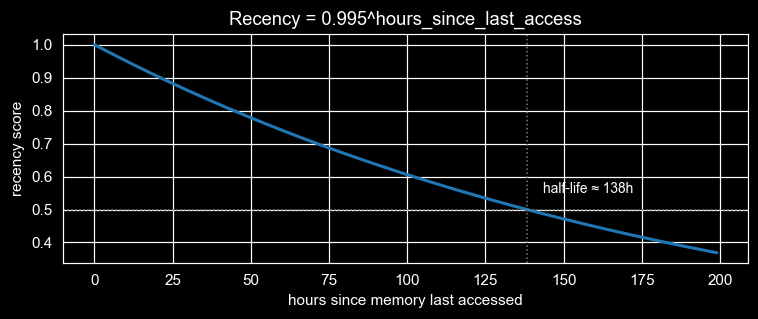

In [4]:
def recency_score(memory, now_hours, decay=0.995):
    hours_elapsed = now_hours - memory.last_accessed
    return decay ** max(hours_elapsed, 0)


# Plot the decay curve
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

hours = np.arange(0, 200)
recency = 0.995 ** hours

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(hours, recency, color='tab:blue', lw=2)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.axvline(np.log(0.5) / np.log(0.995), color='grey', ls=':', lw=1)
ax.set_xlabel('hours since memory last accessed')
ax.set_ylabel('recency score')
ax.set_title('Recency = 0.995^hours_since_last_access')
ax.text(np.log(0.5) / np.log(0.995) + 5, 0.55, f'half-life ≈ {np.log(0.5)/np.log(0.995):.0f}h', fontsize=9)
plt.tight_layout(); plt.show()


### 1.4 Relevance — cosine similarity on embeddings

Each memory and each query is embedded into a vector space (we use `text-embedding-3-small`, 1536 dimensions; the paper used OpenAI's `text-embedding-ada-002`). Relevance is cosine similarity:

$$\text{relevance}(m, q) = \frac{\vec m \cdot \vec q}{\|\vec m\|\,\|\vec q\|}$$

The intuition is the same as document retrieval: pull memories that are *about* the query. "Coffee" should retrieve "got a latte at Hobbs Cafe," not "the bookshelf has a wobbly leg."

In [5]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def relevance_score(memory, query_embedding):
    return cosine(memory.embedding, query_embedding)


# Demo: a tiny stream and a query
demo_stream = MemoryStream('demo')
demo_stream.add('Klaus is writing a research paper on gentrification.', created_at=8.0, importance=7)
demo_stream.add('Klaus brushed his teeth this morning.', created_at=7.0, importance=2)
demo_stream.add('Klaus discussed methodology with his adviser yesterday.', created_at=6.0, importance=6)
demo_stream.add('Klaus had pancakes for breakfast.', created_at=8.5, importance=2)

query = 'What is Klaus working on academically?'
q_emb = embed(query)
relevances = [(m.content, relevance_score(m, q_emb)) for m in demo_stream.memories]

print(f'Query: "{query}"\n')
for content, rel in sorted(relevances, key=lambda x: -x[1]):
    print(f'  rel={rel:.3f}  {content}')


Query: "What is Klaus working on academically?"

  rel=0.649  Klaus is writing a research paper on gentrification.
  rel=0.641  Klaus discussed methodology with his adviser yesterday.
  rel=0.453  Klaus had pancakes for breakfast.
  rel=0.404  Klaus brushed his teeth this morning.


### 1.5 Composite retrieval — putting the three together

Each component is min-max normalised across the candidate memories so they live on a comparable [0, 1] scale, then summed with α = 1 each. The top-$k$ memories by composite score get pulled into the prompt for whatever the agent is about to do.

In [6]:
def normalize(values):
    """Min-max scale a list of floats to [0, 1]. If all equal, return zeros."""
    arr = np.array(values, dtype=float)
    span = arr.max() - arr.min()
    if span < 1e-9:
        return np.zeros_like(arr)
    return (arr - arr.min()) / span


def retrieve(stream, query, now_hours, k=5,
             alpha_recency=1.0, alpha_importance=1.0, alpha_relevance=1.0):
    """Score every memory and return the top-k with their component scores."""
    if not stream.memories:
        return pd.DataFrame()
    q_emb = embed(query)
    rec  = [recency_score(m, now_hours) for m in stream.memories]
    imp  = [m.importance / 10.0 for m in stream.memories]   # already on 0-1
    rel  = [relevance_score(m, q_emb) for m in stream.memories]

    rec_n = normalize(rec)
    imp_n = normalize(imp)
    rel_n = normalize(rel)

    scores = alpha_recency * rec_n + alpha_importance * imp_n + alpha_relevance * rel_n

    df = pd.DataFrame({
        'memory':     [m.content for m in stream.memories],
        'recency':    np.round(rec_n, 3),
        'importance': np.round(imp_n, 3),
        'relevance':  np.round(rel_n, 3),
        'score':      np.round(scores, 3),
    }).sort_values('score', ascending=False).reset_index(drop=True)
    # Mark the top-k as retrieved (would update last_accessed in a real run)
    return df.head(k)


### 1.6 A worked example: Klaus is asked what he's working on

We build Klaus's small memory stream, then ask him a question. Watch the composite score select for memories that are *recent* AND *important* AND *relevant* — not just one of the three.

In [7]:
# Seed Klaus's identity (paragraph parsed into semicolon-delimited memories,
# following the paper's Appendix A convention).
KLAUS_IDENTITY = '''Klaus Mueller is a graduate student at Oak Hill College studying sociology;
he is writing a research paper on the effects of gentrification on low-income communities;
he loves to read and discuss social theory; he is in the early stage of his PhD;
he has been collaborating with Maria Lopez on a project about urban housing policy'''

NOW = 9.0   # 9am, game-hour 9 of day 1

klaus = MemoryStream('Klaus Mueller')
for i, sentence in enumerate(KLAUS_IDENTITY.split(';')):
    sentence = sentence.strip()
    if not sentence:
        continue
    score, _ = rate_importance(sentence)
    # Identity memories are 'created' before the simulation starts (t=0)
    klaus.add(sentence, created_at=0.0, importance=score)

# Add this morning's observations
morning_observations = [
    ('Klaus brushed his teeth.',                                 7.0, ),
    ('Klaus had coffee at Hobbs Cafe.',                          7.5, ),
    ('Klaus saw Maria Lopez at Hobbs Cafe and they chatted briefly about her week.', 7.5, ),
    ('Klaus opened his laptop to work on the gentrification paper.', 8.0, ),
    ('Klaus realised he is missing the citation for the Massey & Denton 1993 paper.', 8.5, ),
]
for content, t in morning_observations:
    score, _ = rate_importance(content)
    klaus.add(content, created_at=t, importance=score)

print(f'Klaus has {len(klaus)} memories.\n')

query = 'What are you working on right now?'
print(f'Query: "{query}"\n')
retrieve(klaus, query, now_hours=NOW, k=5)


Klaus has 10 memories.

Query: "What are you working on right now?"



,memory,recency,importance,relevance,score
0,Klaus opened his laptop to work on the gentrif...,0.94,0.6,1.000,2.540
1,he is writing a research paper on the effects ...,0.00,1.0,0.664,1.664
2,he is in the early stage of his PhD,0.00,1.0,0.663,1.663
3,Klaus realised he is missing the citation for ...,1.00,0.4,0.034,1.434
4,Klaus saw Maria Lopez at Hobbs Cafe and they c...,0.88,0.4,0.104,1.384


### What just happened

The top-ranked memory should be a working-on-paper-and-needs-citation one — high on all three axes (recent, important, relevant). The mundane "brushed teeth" memory is recent but low importance and low relevance, so it falls out. "Klaus is studying sociology" might rank high on importance and relevance but it's old (created at t=0), so the recency component drags it down.

This is the move that makes the architecture more than "stuff everything into the prompt." In a real run, an agent might have *thousands* of memories. The retrieval rule is the bottleneck that decides which handful get conditioned on for the next action.

### Try it: change the query

Re-run `retrieve(klaus, ..., now_hours=NOW)` with these queries and predict the ranking before looking at the output:

- `'How do you take your coffee?'`
- `'Who do you collaborate with?'`
- `'Have you brushed your teeth today?'`

Each should pull a different memory to the top. The third is interesting: trivially relevant, but the importance score caps how high it can rank against more substantive matches.

---

## 2. Reflection — turning observations into beliefs

The memory stream alone gives you good retrieval. It does **not** give you *abstraction*. An agent with 200 memories of *"Klaus walked past the library," "Klaus read until midnight," "Klaus skipped lunch to write"* — but no higher-level memory like *"Klaus is dedicated to research"* — has to re-derive that conclusion every time someone asks. Reflection is the move that lets the agent **summarise its own memories into beliefs**, store the beliefs back as memories, and reflect on those beliefs in turn.

![Park 2023 Figure 7 — Klaus Mueller's reflection tree](4_smallville_assets/fig7_reflection_tree.png)

Two-step process from §4.3 of the paper:

1. **Trigger.** When the sum of recent memories' importance scores crosses a threshold (the paper uses 150), kick off reflection.
2. **Generate questions, then insights.**
   - Take the 100 most recent memories. Ask the LLM: *"Given only the information above, what are 3 most salient high-level questions we can answer about the subjects in the statements?"*
   - For each question, retrieve relevant memories and ask the LLM for *"5 high-level novel insights ... cite the particular records that are the basis for the insights."*
   - Insights are written back to the stream as memories. They can be retrieved like any other memory, and they can themselves trigger further reflection.

We implement a small version with one round of reflection.

In [8]:
IMPORTANCE_TRIGGER = 30   # paper uses 150 over a much longer time horizon


def importance_sum_of_recent(stream, n=20):
    return sum(m.importance for m in stream.memories[-n:])


print(f'Klaus\'s recent importance sum: {importance_sum_of_recent(klaus):.0f} (trigger at {IMPORTANCE_TRIGGER})')


Klaus's recent importance sum: 36 (trigger at 30)


### 2.1 Generate salient questions

Show the LLM the most recent memories; ask it for the 3 questions it would most want answers to in order to *understand* this person.

In [9]:
SALIENT_QUESTIONS_PROMPT = '''Below are statements about {agent_name}'s recent activities and identity:

{memories}

Given only the information above, what are the 3 most salient high-level questions we can answer about the subjects in the statements? Format as a numbered list, one question per line, no explanation.'''


def salient_questions(stream, n_recent=20):
    recent = stream.memories[-n_recent:]
    memory_block = '\n'.join(f'- {m.content}' for m in recent)
    raw = llm(SALIENT_QUESTIONS_PROMPT.format(
        agent_name=stream.agent_name, memories=memory_block,
    ), temperature=0.5)
    # Parse numbered list
    questions = []
    for line in raw.split('\n'):
        line = line.strip().lstrip('0123456789.)- ').strip()
        if line:
            questions.append(line)
    return questions[:3]


qs = salient_questions(klaus)
print('Salient questions about Klaus:\n')
for i, q in enumerate(qs, 1):
    print(f'  {i}. {q}')


Salient questions about Klaus:

  1. What is Klaus Mueller's academic focus and current research topic?
  2. Who is Klaus collaborating with on his project about urban housing policy?
  3. What recent activities has Klaus engaged in outside of his academic work?


### 2.2 For each question, generate insights with citations

For each question, retrieve relevant memories from the stream, then ask the LLM to extract insights — and *cite which memories each insight rests on*. The citation step is what makes reflections traceable; you can chase any insight back to its source observations.

In [10]:
INSIGHTS_PROMPT = '''Statements about {agent_name}, each prefixed with a number:

{numbered_memories}

What 5 high-level insights can you infer from the above statements that help answer this question:

   "{question}"

For each insight, cite the statement numbers (e.g., "[1, 4]") that support it. Format each insight as:
  <insight text> [<citations>]

One insight per line. No preamble.'''


def reflect_on_question(stream, question, k=10):
    """Retrieve top-k memories, generate insights with citations."""
    top = retrieve(stream, question, now_hours=NOW, k=k)
    # Re-fetch the actual Memory objects (retrieve() returns a DataFrame)
    selected = [m for m in stream.memories if m.content in top['memory'].values]
    numbered = '\n'.join(f'{i+1}. {m.content}' for i, m in enumerate(selected))

    raw = llm(INSIGHTS_PROMPT.format(
        agent_name=stream.agent_name,
        numbered_memories=numbered,
        question=question,
    ), temperature=0.5)
    return raw, selected


# Reflect on the first salient question
question = qs[0]
print(f'Reflecting on: "{question}"\n')
insights_text, sourced_memories = reflect_on_question(klaus, question)
print(insights_text)


Reflecting on: "What is Klaus Mueller's academic focus and current research topic?"

Klaus Mueller is pursuing a graduate degree in sociology. [1, 4]  
His current research topic is focused on gentrification and its impact on low-income communities. [2, 9]  
He has a strong interest in social theory, which informs his academic work. [3]  
Klaus is collaborating with a peer, indicating engagement in practical research projects related to his field. [5]  
He is actively working on his research paper, highlighting his commitment to advancing his academic focus. [9, 10]


### 2.3 Write insights back to the stream

Each insight is now itself a memory. It has a timestamp (now), an importance score (the LLM rates it), and an embedding. It can be retrieved by future queries — and it can itself trigger a *deeper* reflection later. This is how the paper's reflection trees grow: insight on insight on observation.

In [11]:
def insights_back_to_memories(stream, insights_text, now_hours):
    """Parse the insights output and add each as a memory."""
    added = []
    for line in insights_text.split('\n'):
        line = line.strip()
        if not line:
            continue
        # Strip leading bullet/number
        line = line.lstrip('0123456789.)- ').strip()
        if len(line) < 10:
            continue
        score, _ = rate_importance(line)
        m = stream.add(line, created_at=now_hours, importance=score)
        added.append(m)
    return added


added = insights_back_to_memories(klaus, insights_text, now_hours=NOW)
print(f'Added {len(added)} reflection memories. Klaus now has {len(klaus)} memories total.\n')

# Re-run the original query — does retrieval now surface the reflection-level beliefs?
query = 'What kind of person is Klaus?'
print(f'Query (post-reflection): "{query}"\n')
retrieve(klaus, query, now_hours=NOW + 0.5, k=5)


Added 5 reflection memories. Klaus now has 15 memories total.

Query (post-reflection): "What kind of person is Klaus?"



,memory,recency,importance,relevance,score
0,"Klaus is collaborating with a peer, indicating...",1.000,0.571,1.000,2.571
1,Klaus Mueller is pursuing a graduate degree in...,1.000,0.429,0.850,2.279
2,Klaus opened his laptop to work on the gentrif...,0.887,0.429,0.839,2.155
3,"He is actively working on his research paper, ...",1.000,1.000,0.097,2.097
4,His current research topic is focused on gentr...,1.000,0.857,0.091,1.948


### What the reflection bought us

Before reflection, asking *"What kind of person is Klaus?"* would retrieve scattered observations: he had coffee, he chatted with Maria, he opened his laptop. Plausible, but not a *characterisation*. After reflection, the stream contains higher-level beliefs the LLM extracted from those observations — and *those* are what surface for an abstract question. The agent now has something to say about *who Klaus is*, not just *what Klaus did*.

This is the move that lets Smallville agents stay coherent over two simulated days. The same memory architecture that fits a few dozen observations into a context window also gives the agent the thing context windows can't: **time-evolved beliefs about itself and others**.

---

## 3. Two agents meet at Hobbs Cafe

<img src="4_smallville_assets/klaus.png" width="48"/> &nbsp; <img src="4_smallville_assets/maria.png" width="48"/>

So far one agent (Klaus) has reacted to a stream of observations on his own. The Smallville paper's headline emergent results — Isabella's Valentine's Day party spreading across 25 agents, Sam Moore's mayoral candidacy diffusing through the social network — depend on what happens when two agents *interact*: each retrieves their own memories, generates an utterance, and writes the conversation back into their own stream. The mechanism is the same as Section 1, run twice with different memory streams.

We do this for two agents.

**The setup.** It is now ~9:30 am. Klaus is at Hobbs Cafe working on his paper (his stream from §1). Maria — Klaus's collaborator — has *also* just arrived. But Maria has had a very different morning: she ran into her neighbour Sam Moore on the way out, and Sam told her he is planning to run for mayor. Klaus does not know this yet.

What we want to see:
1. Two streams, *the same encounter remembered differently* from each side (asymmetric framing).
2. A short conversation produced by alternating retrieval-conditioned LLM calls.
3. After the conversation, ask Klaus *"who is running for mayor?"* — does the information now surface? **This is the diffusion mechanism, in miniature.**

In [12]:
# Maria's identity (parallel to Klaus's seed in §1.6)
MARIA_IDENTITY = '''Maria Lopez is a physics graduate student at Oak Hill College;
she is collaborating with Klaus Mueller on a project about urban housing policy;
she has coffee regularly with her neighbour Sam Moore;
she enjoys live music and goes to gigs at The Willows on weekends'''

maria = MemoryStream('Maria Lopez')
for sentence in MARIA_IDENTITY.split(';'):
    sentence = sentence.strip()
    if not sentence:
        continue
    score, _ = rate_importance(sentence)
    maria.add(sentence, created_at=0.0, importance=score)

# Maria's morning — the key observation is the news from Sam
maria_morning = [
    ('Maria made coffee at home and read the news.',                                            7.0),
    ('Maria ran into Sam Moore at the building entrance.',                                      7.4),
    ('Sam Moore told Maria that he is planning to run for mayor of Oak Hill in the next election.', 7.5),
    ('Sam asked Maria to keep his mayoral candidacy private for now since it is not yet public.', 7.6),
    ('Maria walked over to Hobbs Cafe to get a pastry and read for an hour.',                  8.5),
]
for content, t in maria_morning:
    score, _ = rate_importance(content)
    maria.add(content, created_at=t, importance=score)

# The encounter — same event, written into each stream from each agent's perspective.
# Note the asymmetric framing: each agent sees and remembers themselves as the observer.
ENCOUNTER_TIME = 9.5
klaus.add('Klaus noticed Maria Lopez sit down at the table next to him at Hobbs Cafe.',
          created_at=ENCOUNTER_TIME, importance=4)
maria.add('Maria saw Klaus Mueller working on his laptop at Hobbs Cafe and decided to say hello.',
          created_at=ENCOUNTER_TIME, importance=4)

print(f'Klaus has {len(klaus)} memories. Maria has {len(maria)} memories.')


Klaus has 16 memories. Maria has 10 memories.


### 3.2 The dialogue loop

Each turn, the speaker retrieves memories using the *listener's name + recent utterances* as the query, builds a prompt with their identity-relevant memories and the conversation so far, and produces one utterance. The speakers alternate. Either side can end the conversation by emitting `[END]`.

This is the same `retrieve()` function from §1.5 — the multi-agent version really is just "call the single-agent machinery, twice." There is no new architecture; only new state.

In [13]:
DIALOGUE_PROMPT = '''You are role-playing as {speaker_name} in a casual conversation with {listener_name}.

{speaker_name}'s relevant memories (their own identity and what they recall about {listener_name} or the current situation):
{memories}

Current conversation:
{conversation}

It is {speaker_name}'s turn. Reply with ONE short utterance (1-2 sentences) in {speaker_name}'s voice. Stay in character and draw on the memories where relevant. If the conversation has reached a natural close, reply with [END] only.'''


def dialogue_turn(speaker_stream, listener_name, conversation, now_hours, k=6):
    last_two = '\n'.join(f'{name}: {utt}' for name, utt in conversation[-2:]) if conversation else ''
    query = f'Talking with {listener_name}. {last_two}'.strip()
    retrieved = retrieve(speaker_stream, query, now_hours=now_hours, k=k)
    memories_block = '\n'.join(f'- {row["memory"]}' for _, row in retrieved.iterrows())
    convo_block = '\n'.join(f'{name}: {utt}' for name, utt in conversation) or '(conversation has not yet started)'
    prompt = DIALOGUE_PROMPT.format(
        speaker_name=speaker_stream.agent_name,
        listener_name=listener_name,
        memories=memories_block,
        conversation=convo_block,
    )
    return llm(prompt, temperature=0.7, max_tokens=120).strip()


def run_conversation(streams, max_turns=8, now_hours=ENCOUNTER_TIME):
    """streams: [stream_a, stream_b]. They alternate; stream_a speaks first."""
    conversation = []
    for turn in range(max_turns):
        speaker = streams[turn % 2]
        listener = streams[(turn + 1) % 2].agent_name
        utt = dialogue_turn(speaker, listener, conversation, now_hours=now_hours)
        if utt.upper().startswith('[END]') or utt.strip() == '[END]':
            break
        conversation.append((speaker.agent_name, utt))
    return conversation


# Klaus speaks first (he saw her arrive)
conversation = run_conversation([klaus, maria], max_turns=8, now_hours=ENCOUNTER_TIME)
for name, utt in conversation:
    print(f'{name}: {utt}\n')


Klaus Mueller: Hey Maria, how's your week been? I’ve been buried in my research on gentrification—really fascinating stuff!

Maria Lopez: Maria Lopez: Hi Klaus! My week’s been good, thanks! I just ran into Sam Moore earlier—he's gearing up for his mayoral run, which is exciting. How's your research going?

Klaus Mueller: Klaus Mueller: That sounds really interesting! My research is going well, but it's definitely eye-opening to see how gentrification affects communities like ours. Have you had a chance to talk to Sam about his plans?

Maria Lopez: Maria Lopez: I haven't discussed his plans in detail yet, but I think it’s great he's taking the initiative! It's definitely a crucial time for our community with everything that's going on.

Klaus Mueller: Klaus Mueller: I completely agree, Maria! With gentrification on the rise, having someone like Sam in office could really make a difference for our community.

Maria Lopez: Maria Lopez: Absolutely! I think he has a solid vision for the fut

### 3.3 Asymmetric retrieval — same conversation, different memories

The two agents are using the *same* prompt template and the *same* retrieval rule. But each one is conditioning on their own stream — and those streams hold different memories. Klaus pulls memories about *the paper, Maria's collaboration, his morning at the cafe.* Maria pulls memories about *Sam, the mayoral news, her plans for the day.* If the conversation flowed naturally, the news from Maria's morning is exactly the kind of thing she might bring up — and Klaus, having no prior memory of it, can only react.

This is the *mechanism* underneath Park's emergent diffusion result. There is nothing about "information spreading" in the architecture. The information spreads because, when one agent's relevant memory surfaces, it ends up in their utterance, which ends up in the other agent's *next-turn retrieval context*, which ends up written back as a new memory.

In [14]:
SUMMARY_PROMPT = '''Summarize the following conversation between {agent_a} and {agent_b} in ONE concise sentence, from {focal}'s perspective. Mention any specific information that was learned or shared.

Conversation:
{transcript}

One-sentence summary from {focal}'s perspective:'''


def conversation_summary(conversation, focal_name):
    if not conversation:
        return ''
    speakers = list({name for name, _ in conversation})
    other = next((s for s in speakers if s != focal_name), 'the other person')
    transcript = '\n'.join(f'{name}: {utt}' for name, utt in conversation)
    return llm(SUMMARY_PROMPT.format(
        agent_a=conversation[0][0],
        agent_b=other,
        focal=focal_name,
        transcript=transcript,
    ), temperature=0.3, max_tokens=80).strip()


# Each agent writes their own perspective summary back to their own stream
klaus_summary = conversation_summary(conversation, 'Klaus Mueller')
maria_summary = conversation_summary(conversation, 'Maria Lopez')

POST_CONV = ENCOUNTER_TIME + 0.3
score_k, _ = rate_importance(klaus_summary)
klaus.add(klaus_summary, created_at=POST_CONV, importance=score_k)
score_m, _ = rate_importance(maria_summary)
maria.add(maria_summary, created_at=POST_CONV, importance=score_m)

print(f'Klaus wrote to memory: "{klaus_summary}"  (importance {score_k})')
print(f'Maria wrote to memory: "{maria_summary}"  (importance {score_m})')


Klaus wrote to memory: "I learned from Maria that Sam Moore is running for mayor and that his vision for addressing housing issues could be crucial for our community amid the challenges of gentrification that I’m researching."  (importance 6)
Maria wrote to memory: "In my conversation with Klaus, I learned that he is researching gentrification and we both expressed excitement about Sam Moore's upcoming mayoral run, emphasizing the importance of addressing housing issues to support our community."  (importance 5)


### 3.4 Diffusion check — does Klaus now know about Sam?

Before the conversation, Klaus's stream contained nothing about Sam Moore or the mayoral race; that knowledge lived only in Maria's stream. After the conversation, Klaus's stream contains a summary memory written by *himself* about what he and Maria discussed.

The test: query Klaus's stream with *"Who is running for mayor?"* If the architecture worked as intended, the new conversation-summary memory should rank near the top — Klaus has effectively *learned* the news through normal retrieval, with no special information-passing machinery.

(If the conversation never actually surfaced Maria's news, this query will return mostly noise — which is also a useful negative result and a teaching moment about the brittleness of retrieval-conditioned generation.)

In [15]:
print('=== Klaus, asked about the mayoral race ===\n')
retrieve(klaus, 'Who is running for mayor of Oak Hill?', now_hours=POST_CONV + 0.5, k=4)


=== Klaus, asked about the mayoral race ===



,memory,recency,importance,relevance,score
0,I learned from Maria that Sam Moore is running...,1.000,0.714,1.000,2.714
1,His current research topic is focused on gentr...,0.917,0.857,0.436,2.209
2,"He is actively working on his research paper, ...",0.917,1.000,0.170,2.086
3,Klaus noticed Maria Lopez sit down at the tabl...,0.969,0.429,0.166,1.563


In [16]:
print('=== Maria, asked about the same question (control) ===\n')
retrieve(maria, 'Who is running for mayor of Oak Hill?', now_hours=POST_CONV + 0.5, k=4)


=== Maria, asked about the same question (control) ===



,memory,recency,importance,relevance,score
0,"In my conversation with Klaus, I learned that ...",1.000,1.000,0.493,2.493
1,Sam Moore told Maria that he is planning to ru...,0.761,0.667,1.000,2.428
2,Sam asked Maria to keep his mayoral candidacy ...,0.771,0.667,0.406,1.844
3,Maria saw Klaus Mueller working on his laptop ...,0.969,0.667,0.061,1.696


### What this miniature shows

Two agents, one shared encounter, two divergent memory streams, ~6 turns of dialogue, two perspective summaries written back. That's all the apparatus. The asymmetry between Klaus's retrieval and Maria's retrieval on *"Who is running for mayor?"* is the diffusion mechanism made small enough to fit on a slide.

Park 2023 §7.1 reports that after 2 simulated game-days, *32% of all 25 agents* had heard about Sam Moore's candidacy and *52%* had heard about Isabella's Valentine's Day party — both of which started in a single agent's seed memory. The mechanism scaling those numbers up is exactly what we just ran, repeated thousands of times.

### Group-project sparks for the dialogue layer

- **Hallucinated embellishments** (paper §7.2). Run the conversation 10 times with different seeds. How often does a speaker invent a memory neither agent actually has? The paper reports a 1.3% rate; can you reproduce that order of magnitude?
- **Information-distortion across hops.** Add a third agent. Have Klaus then meet a third person and discuss the mayoral race. Does the news survive the second hop intact, or does it drift? (Park's paper does not run this experiment cleanly — the field is open.)
- **Asymmetric importance.** Maria treats the mayor news as moderately important (Sam asked her to keep it private). What if you re-rate it as *very* important (8/10)? Does that change whether and when it surfaces in the conversation?

---

## 4. What this stripped-down notebook is still not

We have built the *core* of the Smallville architecture — memory + retrieval + reflection — for a single agent reacting to a handful of observations. We have *not* built:

| Cut | Why we cut it | Where to read more |
|---|---|---|
| **Planning** (top-down day plans, recursive 5–15-min decomposition) | Most code, smallest new conceptual move beyond reflection. | Park 2023 §4.4 |
| **Scheduled multi-agent encounters** (who is at which location at which time, perceive-other-agents) | Requires the sandbox scheduler. Our §3 hand-scripted Klaus and Maria meeting; in Smallville the agents *find* each other. | Park 2023 §4.5 |
| **The sandbox itself** (Phaser map, path-finding, environment tree) | Runs in two concurrent servers; conceptually orthogonal to the agent architecture. | The [`generative_agents` repo](https://github.com/joonspk-research/generative_agents) |
| **End-to-end emergent behaviour at scale** (25 agents, Valentine's Day party, info diffusion across the network, 2 game-days) | Requires the scheduler + thousands of dollars in compute. We did the *2-agent miniature* in §3; scaling is bookkeeping. | Park 2023 §7, Fig. 9 |

### Worth knowing for the discussion

The TrueSkill ablation below (paper Fig. 8) is the strongest evidence that the architecture *itself* matters — not just "GPT-3.5 can play characters." Removing memory + reflection + planning collapses the rating; even a human crowdworker beats the no-architecture LLM:

![Park 2023 Figure 8 — TrueSkill ablation](4_smallville_assets/fig8_trueskill_ablation.png)

Cohen's *d* between the no-(reflect, plan, observation) ablation and the full architecture is **8.16** — eight standard deviations.

### The architectural retreat (Park 2024)

A year later, the same first author abandoned this whole memory-stream-plus-reflection apparatus. The 2024 *Generative Agent Simulations of 1,000 People* paper conditions GPT-4o on a 2-hour interview transcript — *just stuffed into the prompt* — and predicts individuals at 85% of their own self-consistency. Worth asking the cohort: was the Smallville architecture wrong, or was it a stopgap before context windows got large enough to make memory-plus-retrieval unnecessary? (See Bhuvanesh's discussion + the 🟩 Park 2024 reading.)

### Group-project sparks

A few directions this notebook opens but does not close:

- **Vary the α weights.** Park sets α_recency = α_importance = α_relevance = 1. What does the retrieval ranking look like if you set α_recency = 3? Does the agent become "forgetful of old commitments"?
- **Replace the importance scorer.** Use a smaller model (`gpt-4o-mini` vs. `gpt-3.5-turbo` vs. an open Llama). Are the importance scores stable? *Calibrated?*
- **Three-agent diffusion chain.** Extend §3 with a third agent. Klaus meets Maria, then Klaus meets Anna later. Does the mayor news survive the second hop intact, or does it drift / get embellished / get dropped? (See also the §3 sparks list.)
- **Reflection-on-reflection.** Manually crank the `IMPORTANCE_TRIGGER` low so reflections fire repeatedly. After 3 rounds, do the agent's beliefs stabilise, drift, or become circular?

Full architecture: [`joonspk-research/generative_agents`](https://github.com/joonspk-research/generative_agents).

---

## What did this run cost?

The cell below prints exact token counts and the dollar cost of *your* run. If you read along with the shipped cache, the cost is $0 — every prompt was a cache hit. If you ran live with your own key, the typical end-to-end cost is well under one US cent.

In [17]:
print_cost_summary()


API calls: 21 live chat + 21 cached chat; 22 live embed + 24 cached embed

model                            in tok    out tok   cost (USD)
----------------------------------------------------------------
gpt-4o-mini                       4,778        663     $0.00111
text-embedding-3-small              803          0     $0.00002
----------------------------------------------------------------
total                                                  $0.00113
